# Making your first SQL query
<!-- #region -->

## SQL Overview

SQL (Structured Query Language) is the widely adopted language used for managing and manipulating data. It's the language that inspired its other popular variants you may have heard of, such as PostgreSQL, MySQL, and more.

In this lesson, you will learn how to make your first SQL query.

## Dataset

To perform your first SQL query, we will be working with one main dataset throughout this course:
- Bank Marketing Data

Source: UCI Machine Learning Repository

URL: https://archive-beta.ics.uci.edu/dataset/222/bank+marketing

Data Citation

Moro,S., Rita,P., and Cortez,P.. (2012). Bank Marketing. UCI Machine Learning Repository. https://doi.org/10.24432/C5K306.

## Data Description

The data is related with direct marketing campaigns of a Portuguese banking institution. The marketing campaigns were based on phone calls. Often, more than one contact to the same client was required, in order to access if the product (bank term deposit) would be ('yes') or not ('no') subscribed.

The data contains the following categories:

1. age (numeric)
2. job: type of job (categorical: 'admin.','blue-collar','entrepreneur','housemaid','management','retired','self-employed','services','student','technician','unemployed','unknown')
3. marital: marital status (categorical: 'divorced','married','single','unknown')
4. education (categorical: 'basic.4y','basic.6y','basic.9y','high.school','illiterate','professional.course','university.degree','unknown')
5. default: has credit in default? (categorical: 'no','yes','unknown')
6. housing: has housing loan? (categorical: 'no','yes','unknown')
7. loan: has personal loan? (categorical: 'no','yes','unknown')
8. contact: contact communication type (categorical: 'cellular','telephone')
9. month: last contact month of year (categorical: 'jan', 'feb', 'mar', ..., 'nov', 'dec')
10. day_of_week: last contact day of the week (categorical: 'mon','tue','wed','thu','fri')
11. duration: last contact duration, in seconds (numeric)
12. campaign: number of contacts performed during this campaign and for this client (numeric)
13. pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric; 999 means client was not previously contacted)
14. previous: number of contacts performed before this campaign and for this client (numeric)
15. poutcome: outcome of the previous marketing campaign (categorical: 'failure','nonexistent','success')
16. y: has the client subscribed a term deposit? (binary: 'yes','no')

<!-- #endregion -->

<!-- #region -->
## Install - execute this once.

This code installs JupySQL, DuckDB, and Pandas in your environment. We will be using these moving forward.

In [ ]:
%pip install jupysql --upgrade duckdb-engine --quiet

## Load the data
We extract the bank marketing data by retrieving it from it's URL download link. The link may be a zip file (which it is in this case), so we extract the zip file, read the file containing the data within the zip file, and clean the data. Finally, we save this cleaned data to it's own seperate file called `bank_cleaned.csv`.

In [ ]:
import sys

sys.path.insert(0, "../../")
import banking  # noqa: E402

_ = banking.BankingData("https://tinyurl.com/jb-bank", "bank")
_.extract_to_csv()

After running this code, you should have `bank_cleaned.csv` in the current directory.

## Load Engine
We now load in our SQL extension that allows us to execute SQL queries in Jupyter Notebooks.

<b>Note</b> Ensure you restart any previous notebook that has the same database name as the one initialized below.

In [ ]:
# Loading in SQL extension
%reload_ext sql
# Initiating a DuckDB database named 'bank.duck.db' to run our SQL queries on
%sql duckdb:///bank.duck.db

## Queries

### Creating Table

Let's start off with loading our `bank_cleaned.csv` file from our local directory to our newly created DuckDB database. Here we `CREATE OR REPLACE TABLE` in DuckDB called 'bank' `FROM` our `bank_cleaned.csv` file. The `read_csv_auto` is a function that helps SQL understand our local .csv file for creation into our database.

In [ ]:
%%sql
CREATE OR REPLACE TABLE bank AS
FROM read_csv_auto('bank_cleaned.csv', header=True, sep=',')

### Simple Query

Now that we have our `bank` table in our DuckDB database, we can run our first query on the table. Let's start off with a simple query that looks at the first five rows from our table.

In [ ]:
%%sql
SELECT *
FROM bank
LIMIT 5

`SELECT`, `FROM` and `LIMIT` are considered "clauses" in SQL. You can think of these clauses as functions that serve specific task. `SELECT` is used to specify what the user wants `FROM` the table. The "*" next to our `SELECT` clause means to "select all" `FROM` our bank table. The `LIMIT` clause tells SQL to show only the top 5 rows from our `SELECT` clause.

#### Filtering
The `WHERE` clause allows users to filter the query on specific conditions. Below, we query the table `WHERE` the "job" variable equals 'unemployed'.

In [ ]:
%%sql
SELECT *
FROM bank
WHERE job = 'unemployed'

The 'unemployed' is in quotes because the "job" variable has values which are strings. If you unfamiliar with strings, you can find a quick introduction here.

We can extend filtering even further by filtering on two or more conditions. This introduces the `AND` and `OR` clauses.

In [ ]:
%%sql
SELECT *
FROM bank
WHERE job = 'unemployed' AND education = 'primary'

This query filters the data `WHERE` "job" equals 'unemployed' `AND` where "education" equals 'primary'. The `OR` clause behaves identically to its verbal counterpart.

In [ ]:
%%sql
SELECT *
FROM bank
WHERE job = 'unemployed' OR job = 'blue-collar'

#### Sorting

We can sort the outputs of our query based on certain conditions. Below, we sort our query by "balance" using the `ORDER BY` clause in `DESC` (descending) order.

In [ ]:
%%sql
SELECT *
FROM bank
ORDER BY balance DESC

To order the query by ascending order, you can omit the `DESC` or add `ASC` in the above SQL statement.

<!-- #endregion -->


### You try: Use JupySQL to perform the queries and answer the questions.

Example: show the first 5 rows of the "job" variable.

In [ ]:
%%sql
SELECT job
FROM bank
LIMIT 5

#### Question 1 (Easy):
Query records where the month is in April ("apr")

<!-- #region -->
<details>

<summary>Answers</summary>

You can use the `WHERE` clause to specify where month equals 'apr'.

In [ ]:
%%sql
SELECT *
FROM bank
WHERE month = 'apr'

</details>
<!-- #endregion -->

#### Question 2 (Medium):
Query the first 5 records where "balance" is greater than or equal to 1000. Sorted this query by ascending order.
<b>Hint</b> Equal, greater than, and less can be represented as =, <, >, respectively. Greater than or equal to can be represented as >=

<!-- #region -->
<details>

<summary>Answers</summary>

You can use the `WHERE` clause and with the greater than operator ">=" to declare records with a balance greater than or equal to 1000. The query is then sorted by balance in descending order in the last line with `ORDER BY` and `DESC`.

In [ ]:
%%sql
SELECT *
FROM bank
WHERE balance >= 1000
ORDER BY balance DESC

</details>
<!-- #endregion -->

#### Question 3 (BONUS):
Show the count of records where 'housing' is 'no' and where 'loan' is yes.

<b>Hint</b> `COUNT()` is a aggregating function in SQL (more on aggregation later!). Try experimenting with `COUNT()` in your `SELECT` clause to see if you can find the correct count.

<!-- #region -->
<details>
<summary>Answers</summary>

You can use `COUNT(*)` to get the count of total records after filtering `WHERE` 'housing' is 'no' and 'loan' is yes.

In [ ]:
%%sql
SELECT COUNT(*)
FROM bank
WHERE housing = 'no' AND loan = 'yes'

</details>
<!-- #endregion -->

<!-- #region -->

### Wrapping Up

To summarize this section, we first introduced our primary dataset we will be using for the next few sections. Then, we ran our first query by first installing `JupySQL` and other packages into our notebook, properly loaded our data with some `Python`, and established a connection to a DuckDB database.

We learned the basics of `SQL` by going over some of its most necessary clauses:

- `SELECT` : "Selects" what to extract from the query. This clause can be followed by a specific variable name or by using "*" to select the whole table.

- `FROM` : Tells SQL what table in the database to run our query on. We used this clause primarily on 'bank' which we first created when setting up our DuckDB database.

- `LIMIT` : Limits the number of rows from our query

- `WHERE` : Filters the query on specific conditions. This clause can be combined with `AND` and `OR` clauses for more complex filters.

- `ORDER BY` : Sorts the output on variables in our query. This clause can include `DESC` to sort by descending order.

These clauses lay the foundation of `SQL`. They will be necessary for our next section, which will introduce aggregation functions. We showed a sneak peek of an aggregation function `COUNT()` in Question 3. More on that in the next section!

#### A Little Extra

As you may have noticed, SQL code is straight forward. It's clauses translate well to what you want SQL to do in natural verbal terms. These clauses make it so easy it's like you are "declaring" SQL to do what you would like it to do. This nature is what defines SQL to be a "declarative programming language".

<a href="https://365datascience.com/tutorials/sql-tutorials/sql-declarative-language/" target="_blank">This article</a> is a great resource if you're curious on this topic.

<!-- #endregion -->

In [2]:
import sqlite3

conn = sqlite3.connect("CompanyDB.db")
cursor = conn.cursor()

print("Database connected successfully!")


Database connected successfully!


In [3]:
cursor.execute("""
CREATE TABLE Employees (
    employee_id INTEGER PRIMARY KEY,
    name TEXT,
    department TEXT,
    salary INTEGER,
    age INTEGER,
    city TEXT
)
""")

conn.commit()

print("Employees table created!")


Employees table created!


In [4]:
cursor.executemany("""
INSERT INTO Employees
(employee_id, name, department, salary, age, city)
VALUES (?, ?, ?, ?, ?, ?)
""", [
    (1, 'Rahul', 'IT', 60000, 25, 'Mumbai'),
    (2, 'Priya', 'HR', 50000, 28, 'Delhi'),
    (3, 'Amit', 'IT', 75000, 30, 'Mumbai'),
    (4, 'Sneha', 'Finance', 65000, 27, 'Pune'),
    (5, 'Arjun', 'IT', 80000, 35, 'Delhi'),
    (6, 'Neha', 'HR', 55000, 26, 'Mumbai'),
    (7, 'Ravi', 'Finance', 70000, 32, 'Pune'),
    (8, 'Anjali', 'IT', 60000, 29, 'Mumbai')
])

conn.commit()

print("Data inserted!")


Data inserted!


In [5]:
cursor.execute("""
SELECT *
FROM Employees
""")

rows = cursor.fetchall()

for row in rows:
    print(row)


(1, 'Rahul', 'IT', 60000, 25, 'Mumbai')
(2, 'Priya', 'HR', 50000, 28, 'Delhi')
(3, 'Amit', 'IT', 75000, 30, 'Mumbai')
(4, 'Sneha', 'Finance', 65000, 27, 'Pune')
(5, 'Arjun', 'IT', 80000, 35, 'Delhi')
(6, 'Neha', 'HR', 55000, 26, 'Mumbai')
(7, 'Ravi', 'Finance', 70000, 32, 'Pune')
(8, 'Anjali', 'IT', 60000, 29, 'Mumbai')


In [7]:
cursor.execute("""
SELECT *
FROM Employees
""")


In [8]:
rows = cursor.fetchall()

for row in rows:
    print(row)


(1, 'Rahul', 'IT', 60000, 25, 'Mumbai')
(2, 'Priya', 'HR', 50000, 28, 'Delhi')
(3, 'Amit', 'IT', 75000, 30, 'Mumbai')
(4, 'Sneha', 'Finance', 65000, 27, 'Pune')
(5, 'Arjun', 'IT', 80000, 35, 'Delhi')
(6, 'Neha', 'HR', 55000, 26, 'Mumbai')
(7, 'Ravi', 'Finance', 70000, 32, 'Pune')
(8, 'Anjali', 'IT', 60000, 29, 'Mumbai')


In [9]:
import sqlite3

conn = sqlite3.connect("CompanyDB.db")
cursor = conn.cursor()

print("Connected!")


Connected!


In [10]:
cursor.execute("""
CREATE TABLE IF NOT EXISTS Employees (
    employee_id INTEGER PRIMARY KEY,
    name TEXT,
    department TEXT,
    salary INTEGER,
    age INTEGER,
    city TEXT
)
""")

conn.commit()

print("Table created!")


Table created!


In [11]:
cursor.execute("""
INSERT OR IGNORE INTO Employees
(employee_id, name, department, salary, age, city)
VALUES
(1, 'Rahul', 'IT', 60000, 25, 'Mumbai')
""")

cursor.execute("""
INSERT OR IGNORE INTO Employees
(employee_id, name, department, salary, age, city)
VALUES
(2, 'Priya', 'HR', 50000, 28, 'Delhi')
""")

cursor.execute("""
INSERT OR IGNORE INTO Employees
(employee_id, name, department, salary, age, city)
VALUES
(3, 'Amit', 'IT', 75000, 30, 'Mumbai')
""")

cursor.execute("""
INSERT OR IGNORE INTO Employees
(employee_id, name, department, salary, age, city)
VALUES
(4, 'Sneha', 'Finance', 65000, 27, 'Pune')
""")

cursor.execute("""
INSERT OR IGNORE INTO Employees
(employee_id, name, department, salary, age, city)
VALUES
(5, 'Arjun', 'IT', 80000, 35, 'Delhi')
""")

cursor.execute("""
INSERT OR IGNORE INTO Employees
(employee_id, name, department, salary, age, city)
VALUES
(6, 'Neha', 'HR', 55000, 26, 'Mumbai')
""")

conn.commit()

print("Employees added!")


Employees added!


In [12]:
cursor.execute("""
SELECT *
FROM Employees
""")

rows = cursor.fetchall()

for row in rows:
    print(row)


(1, 'Rahul', 'IT', 60000, 25, 'Mumbai')
(2, 'Priya', 'HR', 50000, 28, 'Delhi')
(3, 'Amit', 'IT', 75000, 30, 'Mumbai')
(4, 'Sneha', 'Finance', 65000, 27, 'Pune')
(5, 'Arjun', 'IT', 80000, 35, 'Delhi')
(6, 'Neha', 'HR', 55000, 26, 'Mumbai')
(7, 'Ravi', 'Finance', 70000, 32, 'Pune')
(8, 'Anjali', 'IT', 60000, 29, 'Mumbai')


In [14]:
cursor.execute("""
SELECT name
FROM Employees
""")

rows = cursor.fetchall()

for row in rows:
    print(row)


('Rahul',)
('Priya',)
('Amit',)
('Sneha',)
('Arjun',)
('Neha',)
('Ravi',)
('Anjali',)


In [15]:
cursor.execute("""
SELECT *
FROM Employees
WHERE salary > 60000
""")

rows = cursor.fetchall()

for row in rows:
    print(row)


(3, 'Amit', 'IT', 75000, 30, 'Mumbai')
(4, 'Sneha', 'Finance', 65000, 27, 'Pune')
(5, 'Arjun', 'IT', 80000, 35, 'Delhi')
(7, 'Ravi', 'Finance', 70000, 32, 'Pune')


In [16]:
cursor.execute("""
SELECT MAX(salary)
FROM Employees
""")

rows = cursor.fetchall()

for row in rows:
    print(row)


(80000,)


In [17]:
cursor.execute("""
SELECT *
FROM Employees
""")

rows = cursor.fetchall()

for row in rows:
    print(row)


(1, 'Rahul', 'IT', 60000, 25, 'Mumbai')
(2, 'Priya', 'HR', 50000, 28, 'Delhi')
(3, 'Amit', 'IT', 75000, 30, 'Mumbai')
(4, 'Sneha', 'Finance', 65000, 27, 'Pune')
(5, 'Arjun', 'IT', 80000, 35, 'Delhi')
(6, 'Neha', 'HR', 55000, 26, 'Mumbai')
(7, 'Ravi', 'Finance', 70000, 32, 'Pune')
(8, 'Anjali', 'IT', 60000, 29, 'Mumbai')


In [18]:
cursor.execute("""
SELECT name, salary
FROM Employees
""")

rows = cursor.fetchall()

for row in rows:
    print(row)


('Rahul', 60000)
('Priya', 50000)
('Amit', 75000)
('Sneha', 65000)
('Arjun', 80000)
('Neha', 55000)
('Ravi', 70000)
('Anjali', 60000)


In [19]:
cursor.execute("""
SELECT *
FROM Employees
WHERE salary > 60000
""")

rows = cursor.fetchall()

for row in rows:
    print(row)


(3, 'Amit', 'IT', 75000, 30, 'Mumbai')
(4, 'Sneha', 'Finance', 65000, 27, 'Pune')
(5, 'Arjun', 'IT', 80000, 35, 'Delhi')
(7, 'Ravi', 'Finance', 70000, 32, 'Pune')


In [20]:
cursor.execute("""
SELECT *
FROM Employees
WHERE department = 'IT'
AND salary > 60000
""")

rows = cursor.fetchall()

for row in rows:
    print(row)


(3, 'Amit', 'IT', 75000, 30, 'Mumbai')
(5, 'Arjun', 'IT', 80000, 35, 'Delhi')


In [21]:
cursor.execute("""
SELECT *
FROM Employees
WHERE department = 'IT'
OR department = 'HR'
""")

rows = cursor.fetchall()

for row in rows:
    print(row)


(1, 'Rahul', 'IT', 60000, 25, 'Mumbai')
(2, 'Priya', 'HR', 50000, 28, 'Delhi')
(3, 'Amit', 'IT', 75000, 30, 'Mumbai')
(5, 'Arjun', 'IT', 80000, 35, 'Delhi')
(6, 'Neha', 'HR', 55000, 26, 'Mumbai')
(8, 'Anjali', 'IT', 60000, 29, 'Mumbai')


In [22]:
cursor.execute("""
SELECT *
FROM Employees
WHERE department IN ('IT', 'HR')
""")

rows = cursor.fetchall()

for row in rows:
    print(row)


(1, 'Rahul', 'IT', 60000, 25, 'Mumbai')
(2, 'Priya', 'HR', 50000, 28, 'Delhi')
(3, 'Amit', 'IT', 75000, 30, 'Mumbai')
(5, 'Arjun', 'IT', 80000, 35, 'Delhi')
(6, 'Neha', 'HR', 55000, 26, 'Mumbai')
(8, 'Anjali', 'IT', 60000, 29, 'Mumbai')


In [23]:
cursor.execute("""
SELECT *
FROM Employees
ORDER BY salary ASC
""")

rows = cursor.fetchall()

for row in rows:
    print(row)


(2, 'Priya', 'HR', 50000, 28, 'Delhi')
(6, 'Neha', 'HR', 55000, 26, 'Mumbai')
(1, 'Rahul', 'IT', 60000, 25, 'Mumbai')
(8, 'Anjali', 'IT', 60000, 29, 'Mumbai')
(4, 'Sneha', 'Finance', 65000, 27, 'Pune')
(7, 'Ravi', 'Finance', 70000, 32, 'Pune')
(3, 'Amit', 'IT', 75000, 30, 'Mumbai')
(5, 'Arjun', 'IT', 80000, 35, 'Delhi')


In [24]:
cursor.execute("""
SELECT *
FROM Employees
ORDER BY salary DESC
""")

rows = cursor.fetchall()

for row in rows:
    print(row)


(5, 'Arjun', 'IT', 80000, 35, 'Delhi')
(3, 'Amit', 'IT', 75000, 30, 'Mumbai')
(7, 'Ravi', 'Finance', 70000, 32, 'Pune')
(4, 'Sneha', 'Finance', 65000, 27, 'Pune')
(1, 'Rahul', 'IT', 60000, 25, 'Mumbai')
(8, 'Anjali', 'IT', 60000, 29, 'Mumbai')
(6, 'Neha', 'HR', 55000, 26, 'Mumbai')
(2, 'Priya', 'HR', 50000, 28, 'Delhi')


In [25]:
cursor.execute("""
SELECT *
FROM Employees
ORDER BY salary DESC
LIMIT 3
""")

rows = cursor.fetchall()

for row in rows:
    print(row)


(5, 'Arjun', 'IT', 80000, 35, 'Delhi')
(3, 'Amit', 'IT', 75000, 30, 'Mumbai')
(7, 'Ravi', 'Finance', 70000, 32, 'Pune')


In [26]:
cursor.execute("""
SELECT COUNT(*)
FROM Employees
""")

rows = cursor.fetchall()

for row in rows:
    print(row)


(8,)


In [27]:
cursor.execute("""
SELECT COUNT(*) AS total_employees
FROM Employees
""")

rows = cursor.fetchall()

for row in rows:
    print(row)


(8,)


In [28]:
cursor.execute("""
SELECT SUM(salary) AS total_salary
FROM Employees
""")

rows = cursor.fetchall()

for row in rows:
    print(row)


(515000,)


In [29]:
cursor.execute("""
SELECT AVG(salary) AS average_salary
FROM Employees
""")

rows = cursor.fetchall()

for row in rows:
    print(row)


(64375.0,)


In [30]:
cursor.execute("""
SELECT MIN(salary) AS lowest_salary
FROM Employees
""")

rows = cursor.fetchall()

for row in rows:
    print(row)


(50000,)


In [31]:
cursor.execute("""
SELECT MAX(salary) AS highest_salary
FROM Employees
""")

rows = cursor.fetchall()

for row in rows:
    print(row)


(80000,)


In [32]:
cursor.execute("""
SELECT department, COUNT(*)
FROM Employees
GROUP BY department
""")

rows = cursor.fetchall()

for row in rows:
    print(row)


('Finance', 2)
('HR', 2)
('IT', 4)


In [33]:
cursor.execute("""
SELECT department, AVG(salary)
FROM Employees
GROUP BY department
""")

rows = cursor.fetchall()

for row in rows:
    print(row)


('Finance', 67500.0)
('HR', 52500.0)
('IT', 68750.0)


In [34]:
cursor.execute("""
SELECT department, MAX(salary)
FROM Employees
GROUP BY department
""")

rows = cursor.fetchall()

for row in rows:
    print(row)


('Finance', 70000)
('HR', 55000)
('IT', 80000)


In [35]:
cursor.execute("""
SELECT department, COUNT(*)
FROM Employees
GROUP BY department
HAVING COUNT(*) > 1
""")

rows = cursor.fetchall()

for row in rows:
    print(row)


('Finance', 2)
('HR', 2)
('IT', 4)


In [36]:
cursor.execute("""
SELECT DISTINCT department
FROM Employees
""")

rows = cursor.fetchall()

for row in rows:
    print(row)


('IT',)
('HR',)
('Finance',)


In [37]:
cursor.execute("""
SELECT DISTINCT city
FROM Employees
""")

rows = cursor.fetchall()

for row in rows:
    print(row)


('Mumbai',)
('Delhi',)
('Pune',)


In [38]:
cursor.execute("""
SELECT *
FROM Employees
WHERE name LIKE 'A%'
""")

rows = cursor.fetchall()

for row in rows:
    print(row)


(3, 'Amit', 'IT', 75000, 30, 'Mumbai')
(5, 'Arjun', 'IT', 80000, 35, 'Delhi')
(8, 'Anjali', 'IT', 60000, 29, 'Mumbai')


In [39]:
cursor.execute("""
SELECT *
FROM Employees
WHERE name LIKE '%a'
""")

rows = cursor.fetchall()

for row in rows:
    print(row)


(2, 'Priya', 'HR', 50000, 28, 'Delhi')
(4, 'Sneha', 'Finance', 65000, 27, 'Pune')
(6, 'Neha', 'HR', 55000, 26, 'Mumbai')


In [40]:
cursor.execute("""
SELECT MAX(salary)
FROM Employees
WHERE salary < (
    SELECT MAX(salary)
    FROM Employees
)
""")

rows = cursor.fetchall()

for row in rows:
    print(row)


(75000,)


In [41]:
cursor.execute("""
SELECT *
FROM Employees
WHERE salary > (
    SELECT AVG(salary)
    FROM Employees
)
""")

rows = cursor.fetchall()

for row in rows:
    print(row)


(3, 'Amit', 'IT', 75000, 30, 'Mumbai')
(4, 'Sneha', 'Finance', 65000, 27, 'Pune')
(5, 'Arjun', 'IT', 80000, 35, 'Delhi')
(7, 'Ravi', 'Finance', 70000, 32, 'Pune')


In [43]:
cursor.execute("""
CREATE TABLE IF NOT EXISTS Departments (
    department_id INTEGER PRIMARY KEY,
    department_name TEXT,
    manager TEXT
)
""")

conn.commit()


In [44]:
cursor.executemany("""
INSERT OR IGNORE INTO Departments
(department_id, department_name, manager)
VALUES (?, ?, ?)
""", [
    (1, 'IT', 'John'),
    (2, 'HR', 'Meena'),
    (3, 'Finance', 'Robert')
])

conn.commit()


In [45]:
cursor.execute("""
SELECT *
FROM Departments
""")

rows = cursor.fetchall()

for row in rows:
    print(row)


(1, 'IT', 'John')
(2, 'HR', 'Meena')
(3, 'Finance', 'Robert')


In [46]:
cursor.execute("""
SELECT
    Employees.name,
    Employees.department,
    Departments.manager
FROM Employees
INNER JOIN Departments
ON Employees.department = Departments.department_name
""")

rows = cursor.fetchall()

for row in rows:
    print(row)


('Rahul', 'IT', 'John')
('Priya', 'HR', 'Meena')
('Amit', 'IT', 'John')
('Sneha', 'Finance', 'Robert')
('Arjun', 'IT', 'John')
('Neha', 'HR', 'Meena')
('Ravi', 'Finance', 'Robert')
('Anjali', 'IT', 'John')


In [47]:
cursor.execute("""
SELECT
    e.name,
    e.department,
    d.manager
FROM Employees e
INNER JOIN Departments d
ON e.department = d.department_name
""")

rows = cursor.fetchall()

for row in rows:
    print(row)


('Rahul', 'IT', 'John')
('Priya', 'HR', 'Meena')
('Amit', 'IT', 'John')
('Sneha', 'Finance', 'Robert')
('Arjun', 'IT', 'John')
('Neha', 'HR', 'Meena')
('Ravi', 'Finance', 'Robert')
('Anjali', 'IT', 'John')


In [48]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


In [49]:
query = """
SELECT *
FROM Employees
"""

df = pd.read_sql_query(query, conn)

df


,employee_id,name,department,salary,age,city
0,1,Rahul,IT,60000,25,Mumbai
1,2,Priya,HR,50000,28,Delhi
2,3,Amit,IT,75000,30,Mumbai
3,4,Sneha,Finance,65000,27,Pune
4,5,Arjun,IT,80000,35,Delhi
5,6,Neha,HR,55000,26,Mumbai
6,7,Ravi,Finance,70000,32,Pune
7,8,Anjali,IT,60000,29,Mumbai


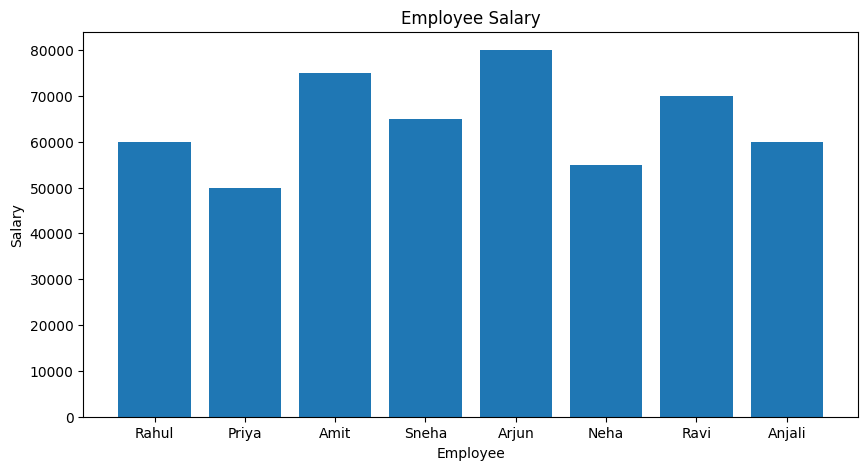

In [50]:
plt.figure(figsize=(10, 5))

plt.bar(df["name"], df["salary"])

plt.xlabel("Employee")
plt.ylabel("Salary")
plt.title("Employee Salary")

plt.show()


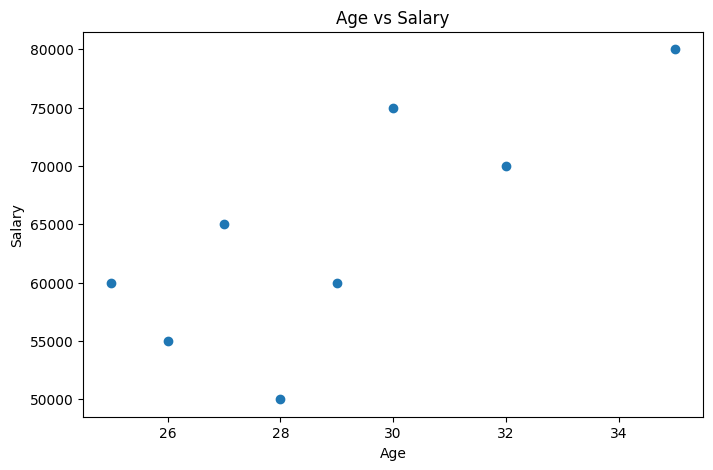

In [51]:
plt.figure(figsize=(8, 5))

plt.scatter(df["age"], df["salary"])

plt.xlabel("Age")
plt.ylabel("Salary")
plt.title("Age vs Salary")

plt.show()


In [52]:
!pip install scikit-learn


In [53]:
from sklearn.linear_model import LinearRegression


In [54]:
X = df[["age"]]
y = df["salary"]


In [55]:
df[["age"]]


,age
0,25
1,28
2,30
3,27
4,35
5,26
6,32
7,29


In [56]:
model = LinearRegression()


In [57]:
model.fit(X, y)


LinearRegression()

In [58]:
print("Slope:", model.coef_[0])


Slope: 2368.421052631578


In [59]:
print("Intercept:", model.intercept_)


Intercept: -4309.210526315757


In [60]:
print("Equation:")
print("Salary =", model.intercept_, "+", model.coef_[0], "* Age")


Equation:
Salary = -4309.210526315757 + 2368.421052631578 * Age


In [61]:
prediction = model.predict([[40]])

print("Predicted salary:", prediction[0])


Predicted salary: 90427.63157894736


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


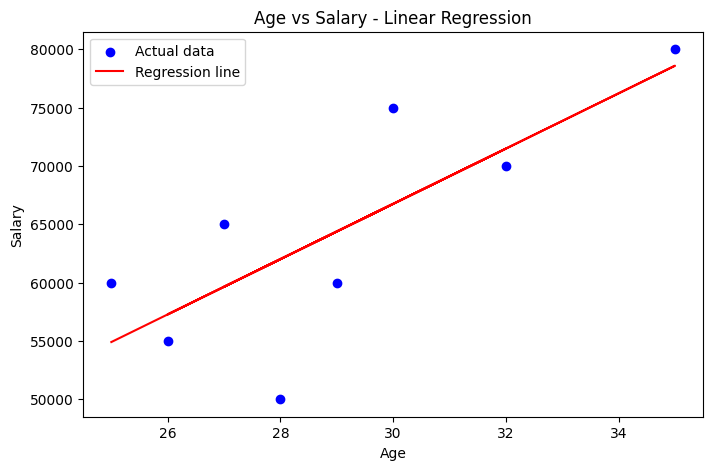

In [62]:
plt.figure(figsize=(8, 5))

plt.scatter(df["age"], df["salary"], color="blue", label="Actual data")

plt.plot(
    df["age"],
    model.predict(df[["age"]]),
    color="red",
    label="Regression line"
)

plt.xlabel("Age")
plt.ylabel("Salary")
plt.title("Age vs Salary - Linear Regression")

plt.legend()
plt.show()


In [63]:
r2 = model.score(X, y)

print("R² Score:", r2)


R² Score: 0.5905673274094324


In [64]:
X = df[["age", "employee_id"]]
y = df["salary"]

model2 = LinearRegression()

model2.fit(X, y)


LinearRegression()

In [65]:
print("Coefficients:", model2.coef_)
print("Intercept:", model2.intercept_)


Coefficients: [2568.31610044 -690.5465288 ]
Intercept: -6998.707533234803


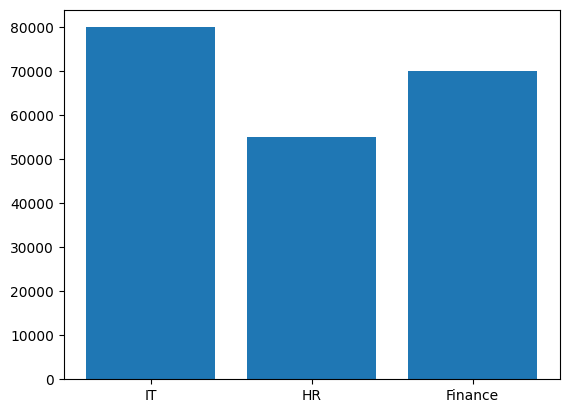

In [67]:
plt.bar(df["department"], df["salary"])
plt.show()


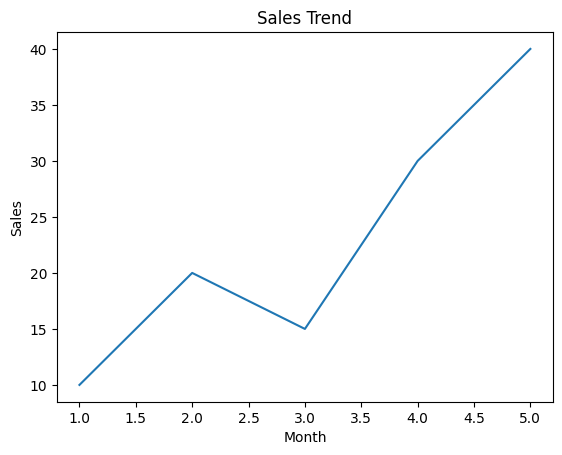

In [68]:
x = [1, 2, 3, 4, 5]
y = [10, 20, 15, 30, 40]

plt.plot(x, y)

plt.xlabel("Month")
plt.ylabel("Sales")
plt.title("Sales Trend")

plt.show()


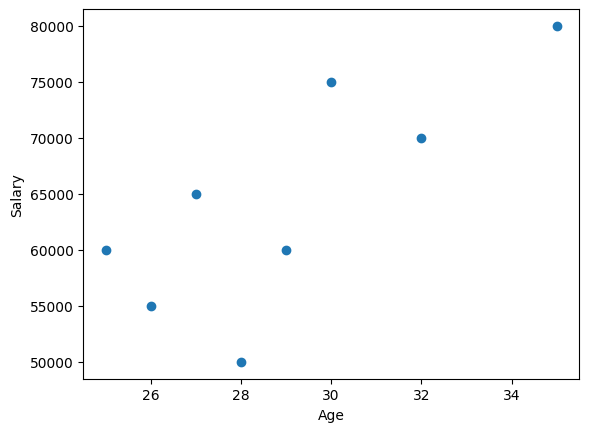

In [69]:
plt.scatter(df["age"], df["salary"])

plt.xlabel("Age")
plt.ylabel("Salary")

plt.show()


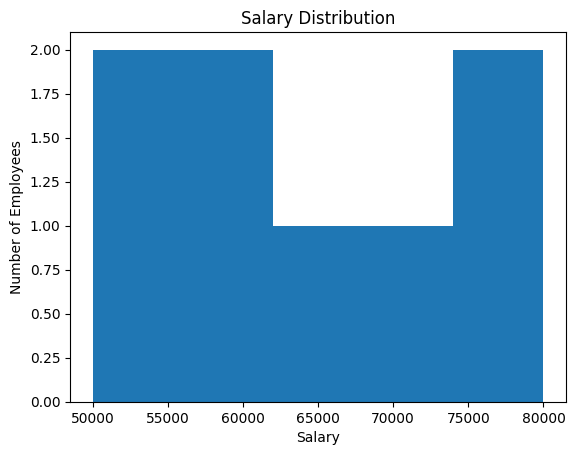

In [70]:
plt.hist(df["salary"], bins=5)

plt.xlabel("Salary")
plt.ylabel("Number of Employees")

plt.title("Salary Distribution")

plt.show()


In [71]:
print(df["age"].corr(df["salary"]))


0.7684837847407274


In [72]:
import seaborn as sns


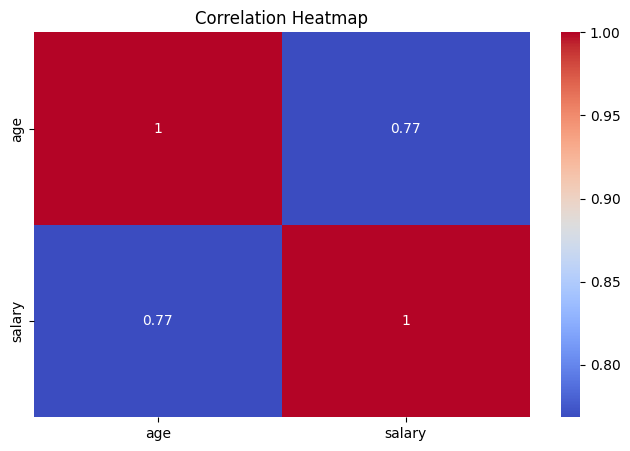

In [73]:
plt.figure(figsize=(8, 5))

sns.heatmap(
    df[["age", "salary"]].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()
